# strict baseline threshold sensitivity visualization

outputs/c1000/threshold_sensitivity.csv

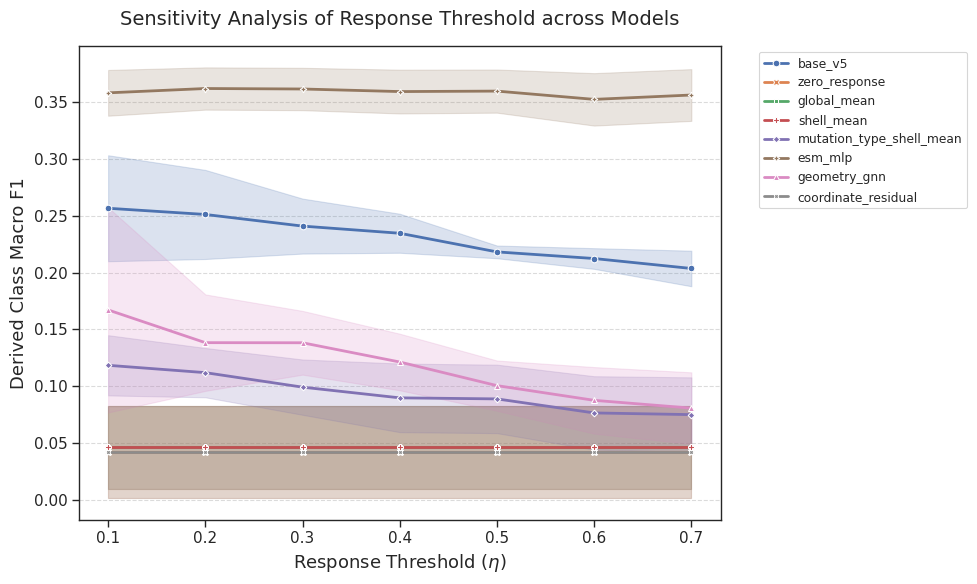

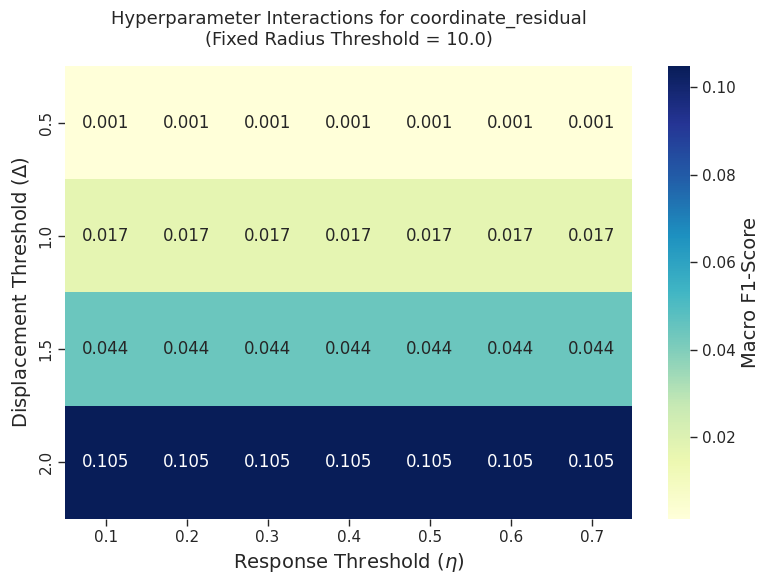

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取数据
df = pd.read_csv("outputs/c1000/threshold_sensitivity.csv")

# 设置学术风格样式
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'xtick.labelsize': 11, 'ytick.labelsize': 11})

# ==========================================
# 可视化方案三：响应阈值的敏感性曲线 (Line Plot)
# ==========================================
plt.figure(figsize=(10, 6))

# 我们对其他的 radius 和 displacement 组合取平均值，观察 response_threshold 的大趋势
sns.lineplot(
    data=df,
    x="response_threshold",
    y="derived_class_macro_f1",
    hue="model_name",
    style="model_name",
    markers=True,
    dashes=False,
    errorbar="sd", # 阴影部分代表在其他超参组合下的标准差
    linewidth=2
)

plt.title("Sensitivity Analysis of Response Threshold across Models", fontsize=14, pad=15)
plt.xlabel("Response Threshold ($\eta$)", fontsize=13)
plt.ylabel("Derived Class Macro F1", fontsize=13)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("response_threshold_sensitivity.png", dpi=300)
plt.show()
plt.close()


# ==========================================
# 可视化方案二：挑选单一模型查看超参热力图 (Heatmap)
# ==========================================
# 假设我们要仔细分析性能较好的 'coordinate_residual' 模型
target_model = "coordinate_residual"
model_df = df[df["model_name"] == target_model]

# 固定一个 radius_threshold (例如 10.0)
fixed_radius = 10.0
heatmap_data = model_df[model_df["radius_threshold"] == fixed_radius]

# 转换成矩阵格式：Row=displacement_threshold, Col=response_threshold
pivot_df = heatmap_data.pivot(
    index="displacement_threshold", 
    columns="response_threshold", 
    values="derived_class_macro_f1"
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_df, 
    annot=True,       # 显示具体数值
    fmt=".3f",        # 保留三位小数
    cmap="YlGnBu",    # 学术常用的蓝绿/黄绿渐变色
    cbar_kws={'label': 'Macro F1-Score'}
)

plt.title(f"Hyperparameter Interactions for {target_model}\n(Fixed Radius Threshold = {fixed_radius})", fontsize=13, pad=15)
plt.xlabel("Response Threshold ($\eta$)")
plt.ylabel("Displacement Threshold ($\Delta$)")
plt.tight_layout()
# plt.savefig(f"{target_model}_heatmap.png", dpi=300)
plt.show()
# plt.close()

# PDB: Large Files

In [ ]:
import glob
import os
import tqdm

pdb_root = '/rds/projects/l/liuje-multiai/shuo/datasets'
pdb_version = 'pdb_260603'
files = glob.glob(f'{pdb_root}/{pdb_version}/pdb/*.gz')
print(len(files))
N_CPUS = len(os.sched_getaffinity(0)) - 2
MAX_FILE_SIZE = 15 * 1024 * 1024

def process_file(f):
	if os.path.getsize(f) > MAX_FILE_SIZE:
		return f, os.path.getsize(f) / 1024 / 1024
	else:
		return None, None

results = []
for res in tqdm.tqdm(files):
	result = process_file(res)
	if result[0] is not None:
		results.append(result)
		
for res in results:
	filename, size_mb = res
	dest_path = filename.replace(f"{pdb_version}/pdb", f"{pdb_version}/large_pdbs")
	os.system(f"mv {filename} {dest_path}")	

254587


100%|██████████| 254587/254587 [01:51<00:00, 2279.75it/s]


# Debug

In [ ]:
import pandas as pd
pred = pd.read_csv('/rds/homes/s/sxz325/shuo/mutation/MuSRNet/outputs/c1000/base_v1/predictions_test.csv')

In [ ]:
pred.keys()

RLIMIT_NOFILE: (262144, 262144)
